<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/04_normal_discrepancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 4 — Add model discrepancy

Keep the angle-and-distance mean model, but acknowledge that the simple mechanism is not exact. Following the case study, approximate each observed proportion with a Normal distribution and add an error term independent of bin size.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,0.28,45198,45183,0.999668
1,0.97,183020,182899,0.999339
2,1.93,169503,168594,0.994637
3,2.92,113094,108953,0.963384
4,3.93,73855,64740,0.876582
5,4.94,53659,41106,0.766060
6,5.94,42991,28205,0.656068
7,6.95,37050,21334,0.575816
8,7.95,33275,16615,0.499324
9,8.95,30836,13503,0.437897


In [3]:
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0

def plot_curve_draws(ax, x, curves):
    """Thin lines for individual draws of the success-probability curve."""
    ax.plot(x, curves, color=DRAW_COLOR, lw=0.8, alpha=0.55, zorder=1.5)

def plot_simulated_datasets(ax, x, datasets):
    """Dots for simulated rates, nudged sideways so nearby values stay visible."""
    jitter = np.random.default_rng(RANDOM_SEED).uniform(-0.15, 0.15, datasets.shape)
    ax.set_autoscalex_on(False)  # keep the same distance axis as the other plots
    ax.scatter(
        np.asarray(x)[:, None] + jitter,
        datasets,
        s=14,
        color=DRAW_COLOR,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.4,
        zorder=1.5,
    )

def add_interval_legend(ax, line_label="mean", draws_label="20 draws", draws_as_points=False):
    """Compact one-row legend above the plot, so it never hides draws or data."""
    if draws_as_points:
        draws_handle = Line2D(
            [0], [0], marker="o", linestyle="none", color=DRAW_COLOR,
            markersize=4, label=draws_label,
        )
    else:
        draws_handle = Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label)
    ax.legend(
        handles=[
            Line2D([0], [0], color="C1", lw=1.6, label=line_label),
            Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
            Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
            draws_handle,
            Line2D(
                [0], [0], marker="o", linestyle="none", color="black",
                markersize=4.5, label="observed",
            ),
        ],
        loc="lower left",
        bbox_to_anchor=(0, 1.01),
        ncols=5,
        fontsize=8,
        handlelength=1.4,
        handletextpad=0.45,
        columnspacing=0.9,
        borderaxespad=0,
        frameon=False,
    )

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model

Let $q_j=y_j/n_j$ be the observed make proportion. We use

$$
q_j\sim N\!\left(p_j,\sqrt{p_j(1-p_j)/n_j+\sigma_{model}^2}\right).
$$

The first variance term is the usual binomial sampling approximation; $\sigma_{model}$ represents mismatch between the simple mechanism and reality.

In [4]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}
with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_distance = pm.LogNormal("sigma_distance", mu=np.log(0.10), sigma=0.7)
    sigma_model = pm.HalfNormal("sigma_model", sigma=0.01)
    overshot = 1.0
    distance_tolerance = 3.0

    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_angle = pm.Deterministic(
        "p_angle",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    p_distance = pm.Deterministic(
        "p_distance",
        pm.math.invprobit((distance_tolerance - overshot) / ((distance + overshot) * sigma_distance))
        - pm.math.invprobit(-overshot / ((distance + overshot) * sigma_distance)),
        dims="obs_id",
    )
    p_base = pm.Deterministic("p_base", p_angle * p_distance, dims="obs_id")
    obs_sigma = pm.Deterministic(
        "obs_sigma",
        pm.math.sqrt(p_base * (1 - p_base) / attempts + sigma_model**2),
        dims="obs_id",
    )
    pm.Normal("rate", mu=p_base, sigma=obs_sigma, observed=golf["rate"].to_numpy(), dims="obs_id")

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior. The dots are 20 simulated datasets, nudged sideways so nearby values stay visible.

The dashed horizontal lines mark the valid probability range. This model can generate values outside $[0,1]$, and the prior predictive display should make that visible rather than clipping it away.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["rate"],
        random_seed=RANDOM_SEED,
    )

Sampling: [rate, sigma_angle_deg, sigma_distance, sigma_model]


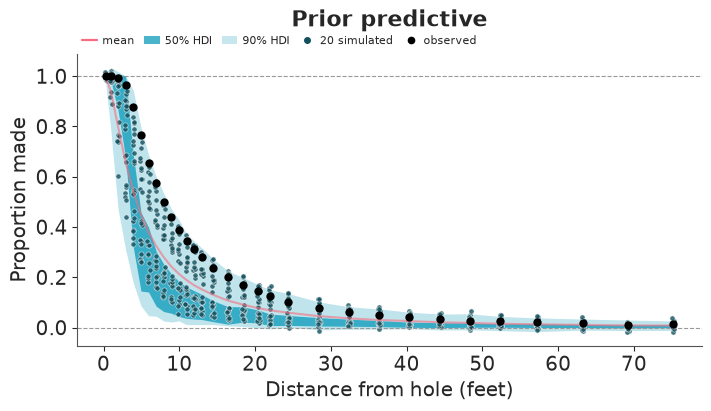

In [6]:
prior_datasets = azb.extract(
    prior,
    group="prior_predictive",
    var_names="rate",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    prior,
    x="distance",
    y="rate",
    y_obs="rate",
    group="prior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, golf["distance_ft"], prior_datasets)
ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made")
ax.set_title("Prior predictive", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
plt.show()

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.92,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_model'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma_angle_deg, sigma_distance, sigma_model]


d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 27 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_deg,1.02,0.01,1.01,1.03,1379.33,1506.21,1.0,0.0,0.0
sigma_distance,0.08,0.00,0.08,0.08,1390.72,1519.71,1.0,0.0,0.0
sigma_model,0.00,0.00,0.00,0.00,1881.90,1658.89,1.0,0.0,0.0


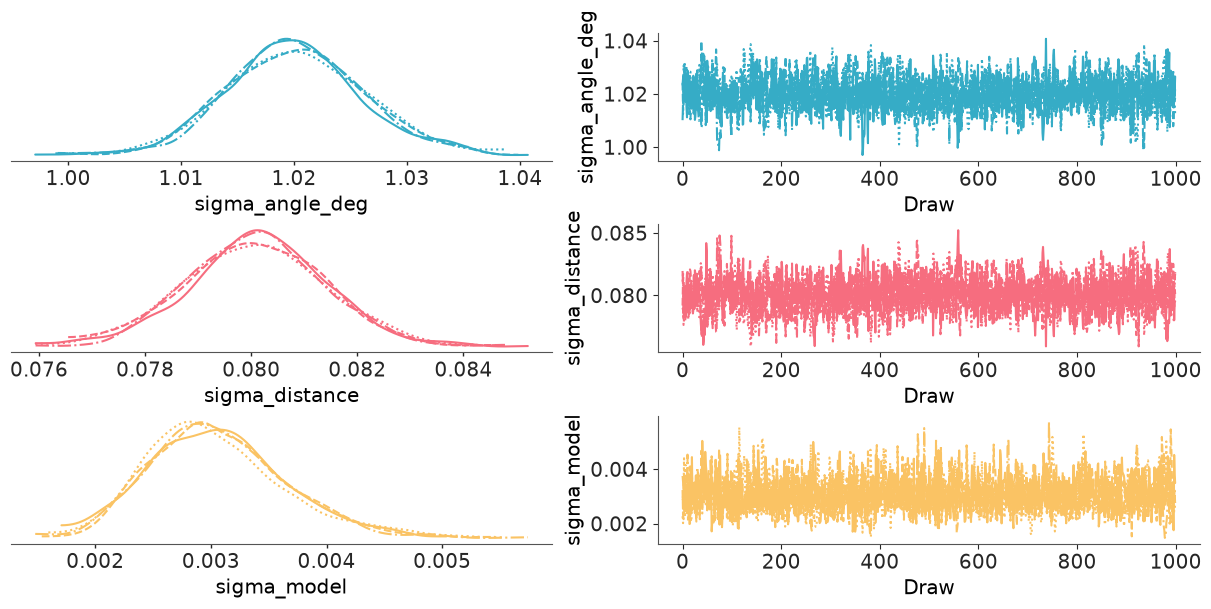

In [8]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_model']);

## Posterior fit

This plot shows posterior uncertainty in the continuous mechanistic success-probability relationship $p_{base}(x)$. It does not include the additional variation in newly observed successes. The thin lines are 20 posterior draws of that curve.

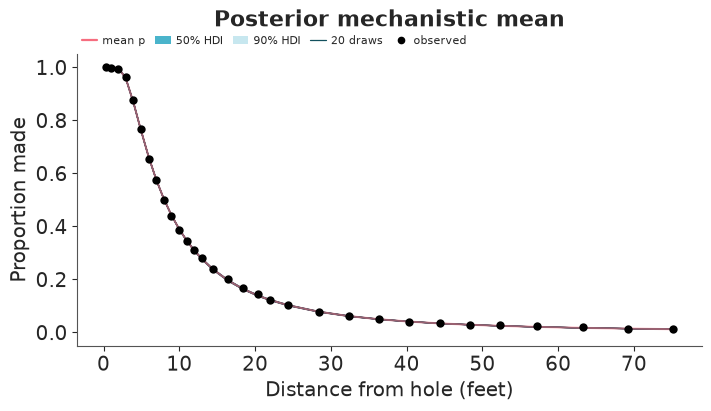

In [9]:
posterior_curves = azb.extract(
    idata,
    group="posterior",
    var_names="p_base",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="distance",
    y="p_base",
    y_obs="rate",
    group="posterior",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_curve_draws(ax, golf["distance_ft"], posterior_curves)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Posterior mechanistic mean", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean p", draws_label="20 draws")
plt.show()

## Posterior predictive check

Now generate new outcomes at the same putting distances from the fitted model. This uses the same graphical grammar as the prior predictive check; the difference is that these predictions are conditioned on the observed data. Each of the 20 simulated datasets comes from the same posterior draw as one of the 20 curves above.

Because the likelihood is Normal on a proportion, posterior predictive draws are also not mathematically restricted to $[0,1]$.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["rate"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [rate]


d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

d:\Repositories\BayesShortCourse\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

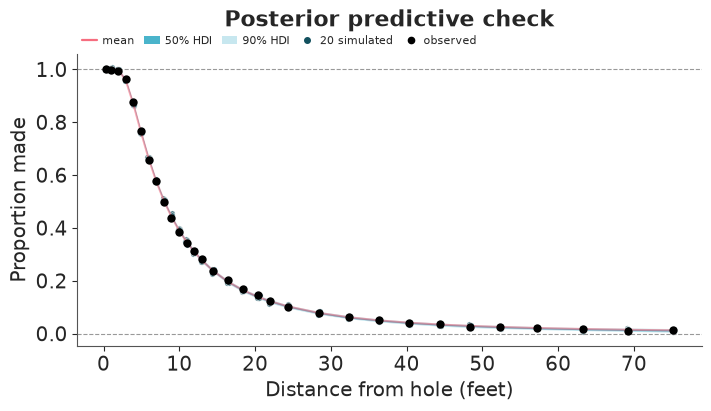

In [11]:
# Same seed and number of draws as the curves above: dataset i uses the same posterior draw as curve i.
posterior_datasets = azb.extract(
    idata,
    group="posterior_predictive",
    var_names="rate",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="distance",
    y="rate",
    y_obs="rate",
    group="posterior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, golf["distance_ft"], posterior_datasets)
ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made")
ax.set_title("Posterior predictive check", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
plt.show()

## Model criticism

These residuals compare the observed rates with the posterior-median mechanistic relationship $p_{base}(x)$. They are a check for systematic structure in the mechanism, not a posterior predictive interval.

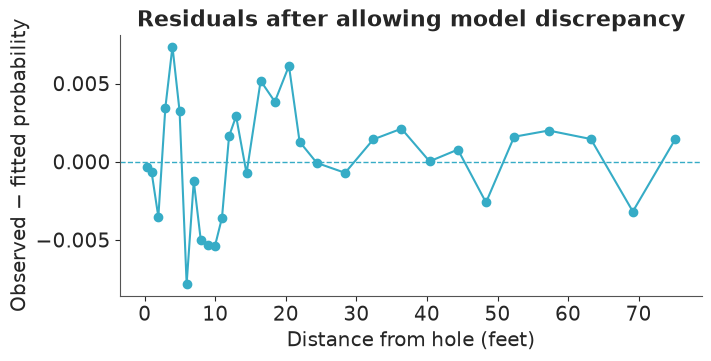

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Residuals after allowing model discrepancy");